In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:13pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:2px;}
table.dataframe{font-size:5xpt;} 
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [4]:
random.randint(140, 195)

154

In [5]:
data = []
for i in range(50):
    # 여자 데이터(몸무게와 키) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(몸무게와 키) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [6]:
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축) :', [female[1] for female in data[::2]])

print('남자 몸무게(x축) :', [male[0] for male in data[1::2]])
print('남자 키(y축) :', [male[1] for male in data[1::2]])

여자 몸무게(x축) : [50, 40, 47, 57, 60, 66, 44, 48, 69, 46, 61, 58, 69, 53, 61, 58, 54, 40, 58, 43, 59, 54, 54, 62, 53, 67, 45, 66, 47, 47, 66, 53, 43, 42, 67, 59, 68, 43, 61, 69, 56, 51, 45, 52, 63, 59, 55, 60, 70, 64]
여자 키(y축) : [141, 164, 145, 144, 168, 164, 169, 146, 159, 151, 148, 169, 144, 150, 140, 161, 153, 144, 161, 142, 162, 169, 159, 151, 168, 149, 157, 168, 144, 160, 160, 164, 160, 149, 160, 162, 162, 147, 155, 162, 150, 157, 141, 140, 149, 148, 152, 143, 170, 147]
남자 몸무게(x축) : [88, 81, 71, 88, 85, 95, 60, 66, 61, 76, 93, 87, 78, 76, 78, 77, 82, 62, 90, 74, 77, 67, 76, 95, 67, 78, 82, 84, 80, 84, 72, 92, 65, 66, 69, 88, 63, 82, 95, 75, 87, 84, 62, 62, 86, 60, 72, 68, 93, 78]
남자 키(y축) : [180, 177, 178, 194, 187, 164, 170, 166, 174, 167, 166, 165, 195, 188, 184, 184, 173, 180, 176, 193, 192, 175, 170, 179, 188, 177, 193, 176, 175, 195, 189, 193, 175, 177, 164, 171, 176, 179, 170, 173, 160, 163, 180, 175, 177, 194, 168, 177, 185, 187]


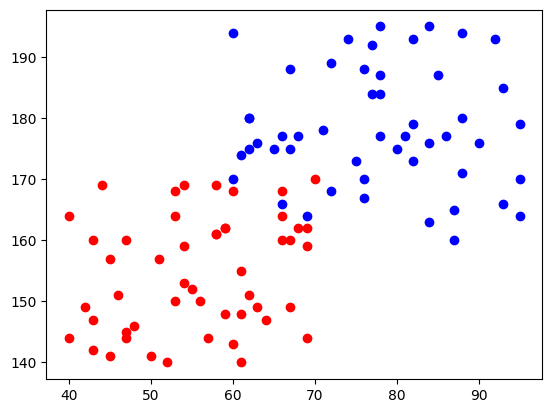

In [7]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]], 'o', color='b')
plt.show()

# 2. 군집화 로직

In [34]:
# 초기 랜덤 지점 2개
random_poinsts = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_poinsts[0], random_poinsts[1]

([89, 144], [88, 144])

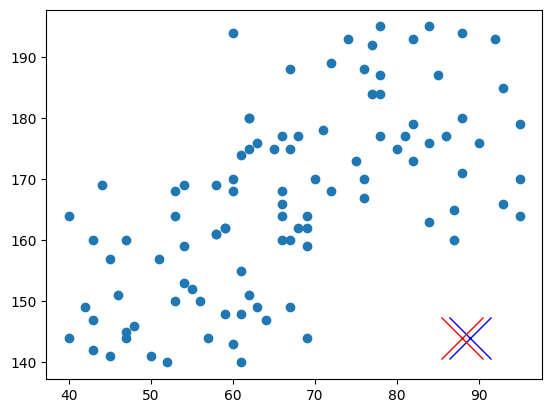

In [35]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b') # 기준점0
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r') # 기준점1

In [38]:
# 두점 거리를 return하는 함수 점은 [50,160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [51]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_poinsts[0], d) < dist(random_poinsts[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(49, 51)

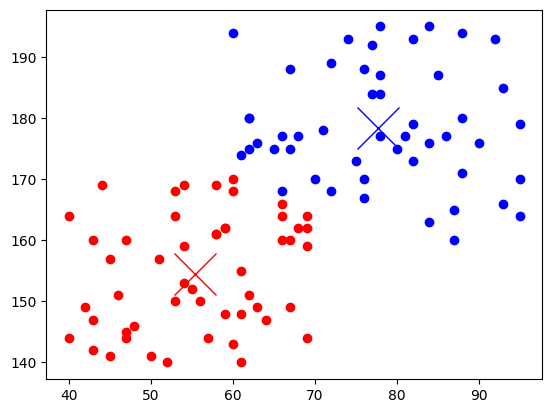

In [52]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

In [53]:
# group0과 group1 중심점으로 기준점을 이동
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_poinsts[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_poinsts[1] = [group1_meanX, group1_meanY]
random_poinsts

[[77.91836734693878, 178.6122448979592],
 [55.705882352941174, 154.7058823529412]]

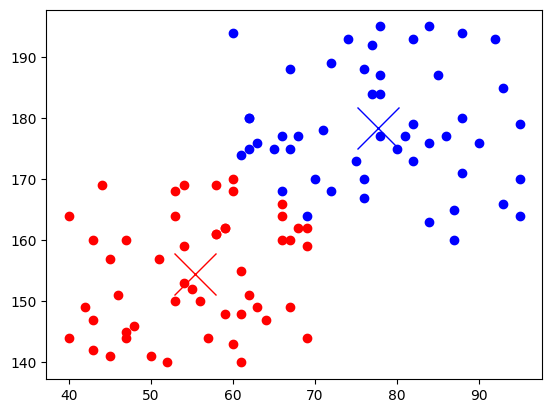

In [50]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_poinsts[0][0], random_poinsts[0][1], 'x', markersize=30, color='b')
plt.plot(random_poinsts[1][0], random_poinsts[1][1], 'x', markersize=30, color='r')
plt.show()

# 3. 군집화 전체 코드(for문 이용)
- 랜덤포인트 2개 지정 - 출력 및 시각화
- for문
    * 랜덤포인드 2지저 기준으로 group0과 group1을 나눔
    * group1의 중간점과 group1의 중간지점을 랜덤포인트로 업데이트
    * 랜덤 포인트 출력 및 시각화

초기 지점 : [[53, 173], [48, 158]]
1 번째 points :  [[74.75, 176.38333333333333], [54.35, 151.475]]
2 번째 points :  [[76.35714285714286, 176.92857142857142], [54.15909090909091, 153.04545454545453]]
3 번째 points :  [[77.01886792452831, 177.62264150943398], [54.829787234042556, 153.7872340425532]]
4 번째 points :  [[77.50980392156863, 178.07843137254903], [55.224489795918366, 154.28571428571428]]
5 번째 points :  [[77.74, 178.32], [55.44, 154.52]]
6 번째 points :  [[77.91836734693878, 178.6122448979592], [55.705882352941174, 154.7058823529412]]
7 번째 points :  [[77.91836734693878, 178.6122448979592], [55.705882352941174, 154.7058823529412]]
8 번째 points :  [[77.91836734693878, 178.6122448979592], [55.705882352941174, 154.7058823529412]]
9 번째 points :  [[77.91836734693878, 178.6122448979592], [55.705882352941174, 154.7058823529412]]
10 번째 points :  [[77.91836734693878, 178.6122448979592], [55.705882352941174, 154.7058823529412]]


(140.0, 195.0)

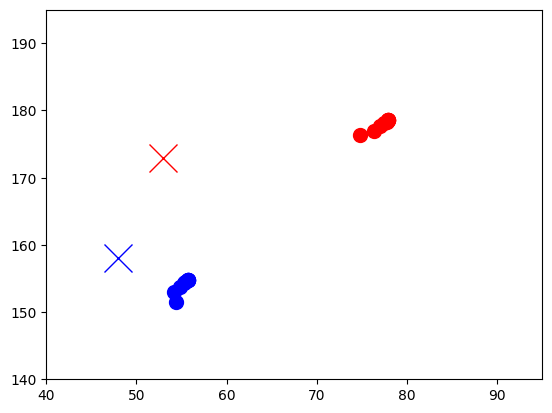

In [61]:
points = [
    [random.randint(40,95), random.randint(140,195)],
    [random.randint(40,95), random.randint(140,195)],
]
print('초기 지점 :', points)
plt.plot(points[0][0], points[0][1], 'x', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'x', color='b', markersize=20)
for i in range(1, 11):
    
    # points 두 지점을 기준으로 group0과 group1 나누기
    group0 = []
    group1 = []
    for info in data:
        if dist(points[0], info) < dist(points[1], info):
            group0.append(info)
        else:
            group1.append(info)
            
    # group0의 중간점, group1의 중간점으로 points업데이트
    meanX = np.mean([g[0] for g in group0])
    meanY = np.mean([g[1] for g in group0])
    points[0] = [meanX, meanY]

    meanX = np.mean([g[0] for g in group1])
    meanY = np.mean([g[1] for g in group1])
    points[1] = [meanX, meanY]

    # 업데이크 된 point 출력 및 시각화
    print(i, '번째 points : ', points)
    plt.plot(points[0][0], points[0][1], 'o', color='r', markersize=10)
    plt.plot(points[1][0], points[1][1], 'o', color='b', markersize=10)
plt.xlim([40, 95])
plt.ylim([140, 195])

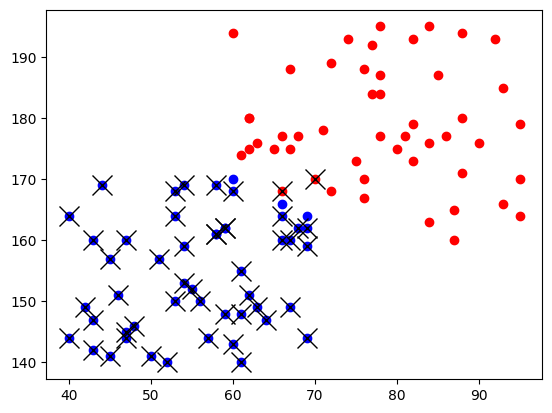

In [68]:
plt.plot([g[0] for g in  group0],
       [g[1] for g in  group0], 'o', color='r')
plt.plot([g[0] for g in  group1],
       [g[1] for g in  group1], 'o', color='b')

plt.plot([female[0] for female in data [::2]],
        [female[1] for female in data [::2]], 'x', color='k', markersize=15)


plt.show()

# 4. api(sklearn)를 이용한 군집화
- sklearn : 머신러닝 패키지
    * 예측모델 : 회귀 분석, 분류 분석, 군집 분석  - fit(학습), predict(예측, 분류)
    * 변환모델 : 전처리시 사용 ex. 인코딩, 스케일조정.. -fit(학습), transform(변환함수), fit_transform(학변)

In [ ]:
# import os
# os.environv['OMP_NUM_THREADS'] = ' 1 ' 
# import warnings
# warnings.filterwarnings(action='ignore') # 경고 무시

In [69]:
from sklearn.cluster import KMeans
data = np.array(data) # 원칙적으로 머신러닝 모델엔 넘파이 배열로 학습
model = KMeans(n_clusters=2, # 2개 그룹으로 군집화
               init='random', # 초기포인트를 random하게
               n_init=10,     # 10번 실행
               random_state=7) # 일관적인 모델을 생성하기 위한 seed값
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [70]:
# 두 그룹의 기준점 : [[77.91836734693878, 178.6122448979592], [55.705882352941174, 154.7058823529412]]
model.cluster_centers_

array([[ 77.91836735, 178.6122449 ],
       [ 55.70588235, 154.70588235]])

In [71]:
# 나누진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0])

In [72]:
group1 = data[model.labels_==1]
group0 = data[model.labels_==0]

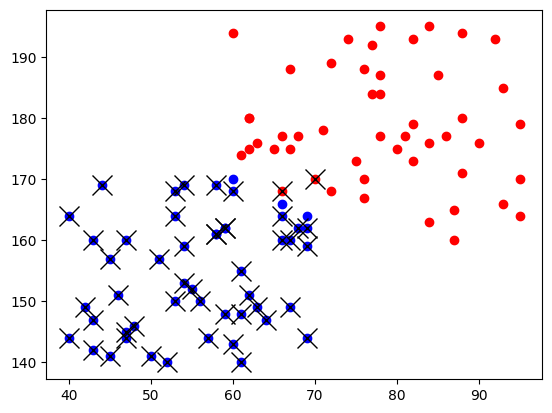

In [73]:
plt.plot([g[0] for g in  group0],
       [g[1] for g in  group0], 'o', color='r')
plt.plot([g[0] for g in  group1],
       [g[1] for g in  group1], 'o', color='b')

plt.plot([female[0] for female in data [::2]],
        [female[1] for female in data [::2]], 'x', color='k', markersize=15)

plt.show()